# NB02: Outcome Variable Comparison

Compare 6 candidate outcome formulations for source and target domains.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


## 1. Source Domain: Morning DO (06:00–09:00)

In [2]:
campaign = pd.read_csv(DATA_DIR + 'data_campaign_flat_clean.csv')
campaign['time_dt'] = pd.to_datetime(campaign['time'], format='%H:%M:%S', errors='coerce')
campaign['hour'] = campaign['time_dt'].dt.hour
campaign['date'] = pd.to_datetime(campaign['date'])

# Morning = 06:00-09:00
morning_src = campaign[(campaign['hour'] >= 6) & (campaign['hour'] <= 9)].copy()
print("Source morning measurements:", morning_src.shape)
print("Date range:", morning_src['date'].min(), "to", morning_src['date'].max())
print("Unique ponds:", morning_src['pond_id'].nunique())

Source morning measurements: (11442, 8)
Date range: 2025-11-29 00:00:00 to 2026-01-30 00:00:00
Unique ponds: 17


In [3]:
SOURCE_LOW_DO_THRESHOLD = 2.176

# Compute daily pond-level morning DO averages
src_pond_daily = morning_src.groupby(['date','pond_id'])['do_mg_l'].mean().reset_index()
src_pond_daily.columns = ['date','pond_id','do_mg_l']

# Compute 6 candidate outcomes per day
src_day = src_pond_daily.groupby('date').agg(
    n_ponds=('do_mg_l','count'),
    mean_do=('do_mg_l','mean'),
    frac_low_25=('do_mg_l', lambda x: (x < SOURCE_LOW_DO_THRESHOLD).mean()),
    frac_low_3=('do_mg_l', lambda x: (x < 3.0).mean()),
    n_low_25=('do_mg_l', lambda x: (x < SOURCE_LOW_DO_THRESHOLD).sum()),
    n_low_3=('do_mg_l', lambda x: (x < 3.0).sum()),
).reset_index()

# Percentile-based outcomes
src_day['bad_day_p10'] = (src_day['mean_do'] <= src_day['mean_do'].quantile(0.10)).astype(int)
src_day['bad_day_p20'] = (src_day['mean_do'] <= src_day['mean_do'].quantile(0.20)).astype(int)
src_day['bad_day_25'] = (src_day['frac_low_25'] > 0).astype(int)
src_day['bad_day_3'] = (src_day['frac_low_3'] > 0).astype(int)
src_day['count_low_25'] = src_day['frac_low_25']
src_day['count_low_3'] = src_day['frac_low_3']

print("Source daily shape:", src_day.shape)
print("Prevalences:")
for col in ['bad_day_p10','bad_day_p20','bad_day_25','bad_day_3']:
    print(f"  {col}: {src_day[col].mean():.3f}")
for col in ['count_low_25','count_low_3','frac_low_3']:
    print(f"  {col} mean: {src_day[col].mean():.3f}, std: {src_day[col].std():.3f}")

Source daily shape: (63, 13)
Prevalences:
  bad_day_p10: 0.111
  bad_day_p20: 0.206
  bad_day_25: 0.937
  bad_day_3: 1.000
  count_low_25 mean: 0.390, std: 0.183
  count_low_3 mean: 0.569, std: 0.180
  frac_low_3 mean: 0.569, std: 0.180


## 3. Target Domain: Water Quality Outcomes

In [4]:
wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
target_wq = wq[
    (wq['region'] == 'Eluru') &
    (wq['Type'] == 'Morning') &
    (wq['Is follow up'] == 'No')
].copy()
target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')
target_wq = target_wq.dropna(subset=['DO'])

print("Target WQ shape:", target_wq.shape)

tgt_day = target_wq.groupby('date').agg(
    n_ponds=('DO','count'),
    mean_do=('DO','mean'),
    frac_low_25=('DO', lambda x: (x < 2.5).mean()),
    frac_low_3=('DO', lambda x: (x < 3.0).mean()),
    n_low_25=('DO', lambda x: (x < 2.5).sum()),
    n_low_3=('DO', lambda x: (x < 3.0).sum()),
).reset_index()

tgt_day['bad_day_p10'] = (tgt_day['mean_do'] <= tgt_day['mean_do'].quantile(0.10)).astype(int)
tgt_day['bad_day_p20'] = (tgt_day['mean_do'] <= tgt_day['mean_do'].quantile(0.20)).astype(int)
tgt_day['bad_day_25'] = (tgt_day['frac_low_25'] > 0).astype(int)
tgt_day['bad_day_3'] = (tgt_day['frac_low_3'] > 0).astype(int)
tgt_day['count_low_25'] = tgt_day['frac_low_25']
tgt_day['count_low_3'] = tgt_day['frac_low_3']

print("Target daily shape:", tgt_day.shape)
print("Prevalences:")
for col in ['bad_day_p10','bad_day_p20','bad_day_25','bad_day_3']:
    print(f"  {col}: {tgt_day[col].mean():.3f}")
for col in ['count_low_25','count_low_3','frac_low_3']:
    print(f"  {col} mean: {tgt_day[col].mean():.3f}, std: {tgt_day[col].std():.3f}")

Target WQ shape: (3368, 56)
Target daily shape: (746, 13)
Prevalences:
  bad_day_p10: 0.101
  bad_day_p20: 0.201
  bad_day_25: 0.261
  bad_day_3: 0.310
  count_low_25 mean: 0.127, std: 0.261
  count_low_3 mean: 0.161, std: 0.295
  frac_low_3 mean: 0.161, std: 0.295


## 4. Prevalence Comparison & Distributional Properties

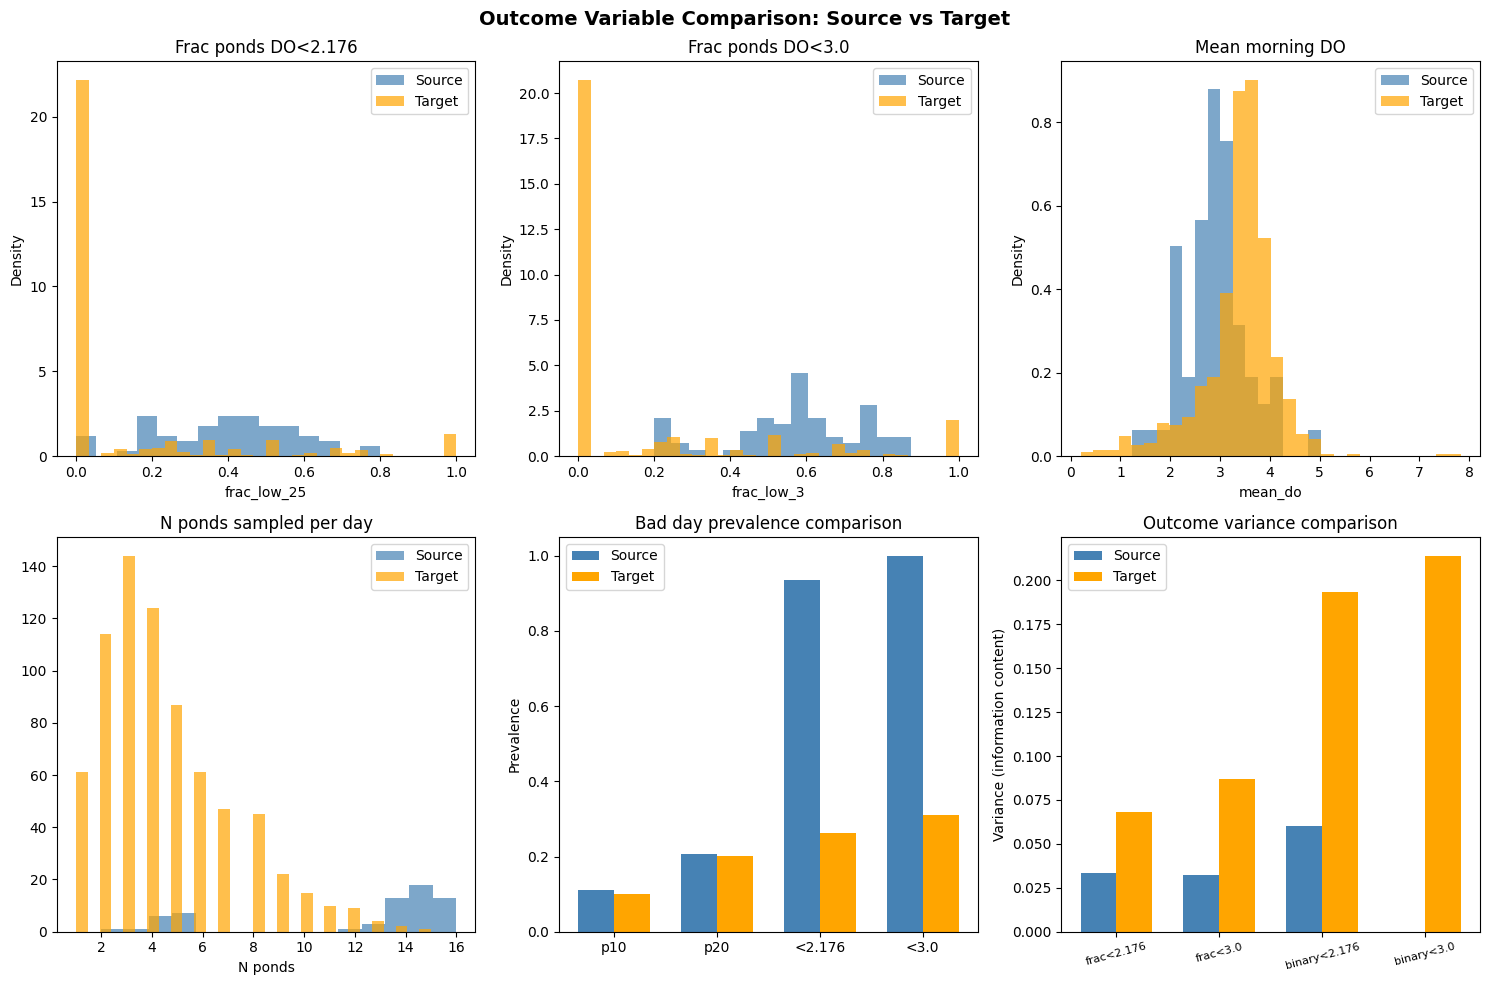

Saved nb02_outcome_comparison.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

outcomes = ['frac_low_25', 'frac_low_3', 'mean_do']
titles = ['Frac ponds DO<2.176', 'Frac ponds DO<3.0', 'Mean morning DO']

for j, (out, title) in enumerate(zip(outcomes, titles)):
    ax = axes[0, j]
    ax.hist(src_day[out].dropna(), bins=15, alpha=0.7, label='Source', color='steelblue', density=True)
    ax.hist(tgt_day[out].dropna(), bins=30, alpha=0.7, label='Target', color='orange', density=True)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(out)
    ax.set_ylabel('Density')

# n_ponds distributions
ax = axes[1, 0]
ax.hist(src_day['n_ponds'].dropna(), bins=15, alpha=0.7, label='Source', color='steelblue')
ax.hist(tgt_day['n_ponds'].dropna(), bins=30, alpha=0.7, label='Target', color='orange')
ax.set_title('N ponds sampled per day')
ax.legend()
ax.set_xlabel('N ponds')

# Effective sample size comparison
ax = axes[1, 1]
outcomes_binary = ['bad_day_p10', 'bad_day_p20', 'bad_day_25', 'bad_day_3']
prevalences_src = [src_day[c].mean() for c in outcomes_binary]
prevalences_tgt = [tgt_day[c].mean() for c in outcomes_binary]
x = np.arange(len(outcomes_binary))
width = 0.35
ax.bar(x - width/2, prevalences_src, width, label='Source', color='steelblue')
ax.bar(x + width/2, prevalences_tgt, width, label='Target', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['p10','p20','<2.176','<3.0'], rotation=0)
ax.set_ylabel('Prevalence')
ax.set_title('Bad day prevalence comparison')
ax.legend()

# Information content: variance of each formulation
ax = axes[1, 2]
info_src = [src_day['frac_low_25'].var(), src_day['frac_low_3'].var(), 
            src_day['bad_day_25'].var(), src_day['bad_day_3'].var()]
info_tgt = [tgt_day['frac_low_25'].var(), tgt_day['frac_low_3'].var(),
            tgt_day['bad_day_25'].var(), tgt_day['bad_day_3'].var()]
labels = ['frac<2.176', 'frac<3.0', 'binary<2.176', 'binary<3.0']
ax.bar(x - width/2, info_src, width, label='Source', color='steelblue')
ax.bar(x + width/2, info_tgt, width, label='Target', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, fontsize=8)
ax.set_ylabel('Variance (information content)')
ax.set_title('Outcome variance comparison')
ax.legend()

plt.suptitle('Outcome Variable Comparison: Source vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb02_outcome_comparison.png', dpi=80, bbox_inches='tight')
plt.show()
print("Saved nb02_outcome_comparison.png")

## 5. n_ponds Distributions

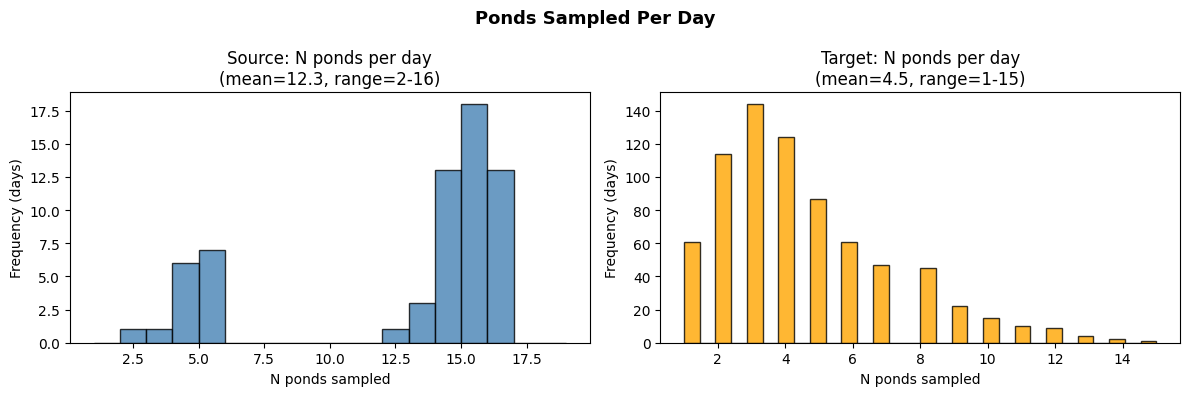

Source: mean n_ponds=12.3, median=14
Target: mean n_ponds=4.5, median=4


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.hist(src_day['n_ponds'], bins=range(1, 20), alpha=0.8, color='steelblue', edgecolor='black')
ax.set_title(f'Source: N ponds per day\n(mean={src_day["n_ponds"].mean():.1f}, range={src_day["n_ponds"].min()}-{src_day["n_ponds"].max()})')
ax.set_xlabel('N ponds sampled')
ax.set_ylabel('Frequency (days)')

ax = axes[1]
ax.hist(tgt_day['n_ponds'], bins=30, alpha=0.8, color='orange', edgecolor='black')
ax.set_title(f'Target: N ponds per day\n(mean={tgt_day["n_ponds"].mean():.1f}, range={tgt_day["n_ponds"].min()}-{tgt_day["n_ponds"].max()})')
ax.set_xlabel('N ponds sampled')
ax.set_ylabel('Frequency (days)')

plt.suptitle('Ponds Sampled Per Day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb02_n_ponds_distributions.png', dpi=80, bbox_inches='tight')
plt.show()

print(f"Source: mean n_ponds={src_day['n_ponds'].mean():.1f}, median={src_day['n_ponds'].median():.0f}")
print(f"Target: mean n_ponds={tgt_day['n_ponds'].mean():.1f}, median={tgt_day['n_ponds'].median():.0f}")

## 6. Power Simulation: Binomial vs Binary

Power simulation (effect_size=0.1, n_days=100, n_ponds=10):


  Binomial fraction: 0.266
  Binary: 0.078
  Power gain from Binomial: 241.0%


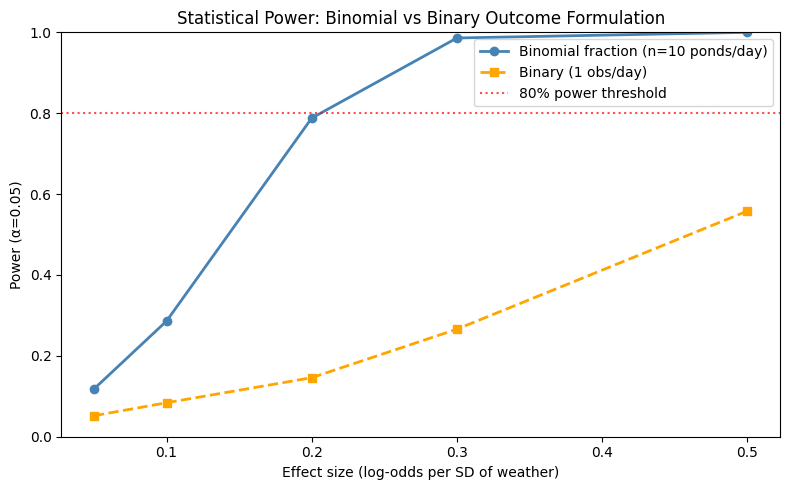

Saved nb02_power_comparison.png


In [7]:
# Simulate power to detect a weather effect: Binomial fraction vs binary
np.random.seed(42)

def sim_power(effect_size=0.1, n_days=100, n_ponds_per_day=10, n_sim=500, use_binomial=True):
    """Simulate power of test for weather effect."""
    pvals = []
    for _ in range(n_sim):
        X = np.random.randn(n_days)
        p_base = 0.3
        p_true = 1 / (1 + np.exp(-(np.log(p_base/(1-p_base)) + effect_size * X)))
        if use_binomial:
            n = np.random.randint(max(1, n_ponds_per_day-3), n_ponds_per_day+3, n_days)
            y = np.random.binomial(n, p_true) / n
        else:
            y = (np.random.rand(n_days) < p_true).astype(float)
        r, p = stats.pearsonr(X, y)
        pvals.append(p < 0.05)
    return np.mean(pvals)

print("Power simulation (effect_size=0.1, n_days=100, n_ponds=10):")
power_binom = sim_power(use_binomial=True, n_ponds_per_day=10)
power_binary = sim_power(use_binomial=False, n_ponds_per_day=10)
print(f"  Binomial fraction: {power_binom:.3f}")
print(f"  Binary: {power_binary:.3f}")
print(f"  Power gain from Binomial: {(power_binom/power_binary - 1)*100:.1f}%")

# Effect sizes
effect_sizes = [0.05, 0.1, 0.2, 0.3, 0.5]
powers_binom = [sim_power(e, use_binomial=True, n_ponds_per_day=10) for e in effect_sizes]
powers_binary = [sim_power(e, use_binomial=False, n_ponds_per_day=10) for e in effect_sizes]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(effect_sizes, powers_binom, 'o-', color='steelblue', label='Binomial fraction (n=10 ponds/day)', linewidth=2)
ax.plot(effect_sizes, powers_binary, 's--', color='orange', label='Binary (1 obs/day)', linewidth=2)
ax.axhline(0.8, color='red', linestyle=':', alpha=0.7, label='80% power threshold')
ax.set_xlabel('Effect size (log-odds per SD of weather)')
ax.set_ylabel('Power (α=0.05)')
ax.set_title('Statistical Power: Binomial vs Binary Outcome Formulation')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb02_power_comparison.png', dpi=80, bbox_inches='tight')
plt.show()
print("Saved nb02_power_comparison.png")

## Summary & Recommendation

In [8]:
print("=" * 60)
print("OUTCOME VARIABLE RECOMMENDATION")
print("=" * 60)
print()
print("Recommended: Binomial count (n_low_3 / n_total)")
print("  Threshold: DO < 3.0 mg/L")
print()
print(f"Source prevalence: {src_day['frac_low_3'].mean():.3f} (frac ponds per day)")
print(f"Target prevalence: {tgt_day['frac_low_3'].mean():.3f} (frac ponds per day)")
print()
print("Rationale:")
print("  1. DO < 3 mg/L is biologically meaningful threshold for fish stress")
print("  2. Binomial formulation uses full count info (more power than binary)")
print("  3. frac_low_3 has sufficient variance in both domains")
print("  4. Compatible with Beta-Binomial likelihood (handles overdispersion)")
print()
src_day['domain'] = 'source'
tgt_day['domain'] = 'target'
print("Source frac_low_3 stats:", src_day['frac_low_3'].describe().round(3).to_dict())
print("Target frac_low_3 stats:", tgt_day['frac_low_3'].describe().round(3).to_dict())

OUTCOME VARIABLE RECOMMENDATION

Recommended: Binomial count (n_low_3 / n_total)
  Threshold: DO < 3.0 mg/L

Source prevalence: 0.569 (frac ponds per day)
Target prevalence: 0.161 (frac ponds per day)

Rationale:
  1. DO < 3 mg/L is biologically meaningful threshold for fish stress
  2. Binomial formulation uses full count info (more power than binary)
  3. frac_low_3 has sufficient variance in both domains
  4. Compatible with Beta-Binomial likelihood (handles overdispersion)

Source frac_low_3 stats: {'count': 63.0, 'mean': 0.569, 'std': 0.18, 'min': 0.2, '25%': 0.5, '50%': 0.6, '75%': 0.701, 'max': 0.875}
Target frac_low_3 stats: {'count': 746.0, 'mean': 0.161, 'std': 0.295, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.223, 'max': 1.0}


## Iteration 2: Beta-Binomial vs Binomial AIC, Threshold Sensitivity, Sub-season Gap

In [9]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import betabinom, binom
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
src = pd.read_csv(DATA_DIR + 'nb04_source_features.csv', parse_dates=['date'])
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])

def neg_loglik_binomial(params, k, n):
    p = 1 / (1 + np.exp(-params[0]))
    return -np.sum(binom.logpmf(k, n, p))

def neg_loglik_betabinom(params, k, n):
    mu = 1 / (1 + np.exp(-params[0]))
    kappa = np.exp(params[1]) + 1e-6
    a = mu * kappa; b = (1 - mu) * kappa
    if a <= 0 or b <= 0: return 1e10
    return -np.sum(betabinom.logpmf(k, n, a, b))

def compute_aic_bic(nll, k_params, n):
    aic = 2*k_params + 2*nll
    bic = k_params*np.log(n) + 2*nll
    return aic, bic

for label, df in [('Source', src), ('Target', tgt)]:
    n_col = 'n_ponds' if 'n_ponds' in df.columns else 'n_total'
    df2 = df.dropna(subset=['frac_low',n_col])
    n = df2[n_col].astype(int).values
    k = (df2['frac_low'] * n).round().astype(int).values
    valid = n > 0
    k, n = k[valid], n[valid]

    res_bin = minimize(neg_loglik_binomial, [0.0], args=(k,n), method='Nelder-Mead')
    res_bb  = minimize(neg_loglik_betabinom, [0.0, np.log(5)], args=(k,n), method='Nelder-Mead')

    aic_bin, bic_bin = compute_aic_bic(res_bin.fun, 1, len(k))
    aic_bb,  bic_bb  = compute_aic_bic(res_bb.fun,  2, len(k))

    mu_bin = 1/(1+np.exp(-res_bin.x[0]))
    mu_bb  = 1/(1+np.exp(-res_bb.x[0]))
    kappa  = np.exp(res_bb.x[1])

    print(f"\n{label}:")
    print(f"  Binomial:    p={mu_bin:.3f}, AIC={aic_bin:.1f}, BIC={bic_bin:.1f}")
    print(f"  BetaBinom:   p={mu_bb:.3f}, kappa={kappa:.2f}, AIC={aic_bb:.1f}, BIC={bic_bb:.1f}")
    print(f"  ΔAIC (BetaBin - Bin) = {aic_bb - aic_bin:.1f}  (negative = BetaBin wins)")



Source:
  Binomial:    p=0.643, AIC=228.6, BIC=230.5
  BetaBinom:   p=0.640, kappa=49.06, AIC=229.0, BIC=232.9
  ΔAIC (BetaBin - Bin) = 0.4  (negative = BetaBin wins)

Target:
  Binomial:    p=0.144, AIC=2003.8, BIC=2008.4
  BetaBinom:   p=0.157, kappa=1.31, AIC=1523.1, BIC=1532.3
  ΔAIC (BetaBin - Bin) = -480.7  (negative = BetaBin wins)


In [10]:
# ── Threshold sensitivity ────────────────────────────────────────────────────
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
print(f"\n{'Threshold':>10} {'Src frac_low':>14} {'Tgt frac_low':>14} {'Gap':>8}")
print("-"*50)
for thresh in thresholds:
    src2 = src.dropna(subset=['frac_low'])
    tgt2 = tgt.dropna(subset=['frac_low'])
    s_mean = (src2['frac_low'] >= thresh).mean()
    t_mean = (tgt2['frac_low'] >= thresh).mean()
    print(f"{thresh:>10.1f} {s_mean:>14.3f} {t_mean:>14.3f} {s_mean-t_mean:>8.3f}")



 Threshold   Src frac_low   Tgt frac_low      Gap
--------------------------------------------------
       0.1          1.000          0.302    0.698
       0.2          1.000          0.276    0.724
       0.3          0.925          0.210    0.714
       0.4          0.925          0.173    0.752
       0.5          0.830          0.160    0.671


In [11]:
# ── Sub-season gap analysis ─────────────────────────────────────────────────
def get_season(month):
    if month in [12,1,2]: return 'winter'
    elif month in [3,4,5]: return 'pre_monsoon'
    elif month in [6,7,8,9]: return 'monsoon'
    else: return 'post_monsoon'

src['season'] = pd.to_datetime(src['date']).dt.month.map(get_season)
tgt['season'] = pd.to_datetime(tgt['date']).dt.month.map(get_season)

print("\nSub-season frac_low comparison (threshold=0.3):")
print(f"{'Season':<15} {'Src frac_low':>13} {'Tgt frac_low':>13} {'Src n':>7} {'Tgt n':>7}")
print("-"*60)
for season in ['winter','pre_monsoon','monsoon','post_monsoon']:
    s = src[src.season==season]['frac_low'].dropna()
    t = tgt[tgt.season==season]['frac_low'].dropna()
    if len(s)==0 or len(t)==0:
        print(f"{season:<15} {'no data':>13} {'no data':>13}")
        continue
    print(f"{season:<15} {s.mean():>13.3f} {t.mean():>13.3f} {len(s):>7} {len(t):>7}")



Sub-season frac_low comparison (threshold=0.3):
Season           Src frac_low  Tgt frac_low   Src n   Tgt n
------------------------------------------------------------
winter                  0.621         0.112      53     199
pre_monsoon           no data       no data
monsoon               no data       no data
post_monsoon          no data       no data
